In [460]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/processed/icu_analytics_v2.csv"
)

df.head()

,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,hospitaladmitsource,hospitaldischargestatus,...,n_medication_records,n_lab_records,apache_score,predicted_icu_mortality,predicted_icu_los,actual_vent_days,apache_version,ventilation_status,ventilation_data_available,age_numeric
0,141764,129391,Female,87,Caucasian,59,91,NaN,NaN,Alive,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,NaN,87.0
1,141765,129391,Female,87,Caucasian,59,91,"Rhythm disturbance (atrial, supraventricular)",NaN,Alive,...,14.0,72.0,47.0,0.012311,1.374807,NaN,IVa,Unknown,0.0,87.0
2,143870,131022,Male,76,Caucasian,68,103,"Endarterectomy, carotid",Operating Room,Alive,...,40.0,49.0,60.0,0.015707,3.021671,NaN,IVa,Unknown,0.0,76.0
3,144815,131736,Female,34,Caucasian,56,82,"Overdose, other toxin, poison or drug",Emergency Department,Alive,...,5.0,74.0,25.0,0.002133,0.806311,NaN,IVa,Unknown,0.0,34.0
4,145427,132209,Male,61,Caucasian,68,103,"GI perforation/rupture, surgery for",Emergency Department,Alive,...,40.0,94.0,37.0,0.007556,3.503540,NaN,IVa,Unknown,0.0,61.0


In [461]:
df.shape

(2520, 30)

In [462]:
df["age_numeric"] = pd.to_numeric(
    df["age"].replace("> 89", "90"),
    errors="coerce"
)

In [463]:
df["age_numeric"].describe()

count    2516.000000
mean       63.281002
std        17.764847
min        15.000000
25%        53.000000
50%        66.000000
75%        77.000000
max        90.000000
Name: age_numeric, dtype: float64

In [464]:
los_threshold = df["los_days"].quantile(0.75)

print("Threshold de LOS prolongado:", los_threshold)

Threshold de LOS prolongado: 2.776736111111111


In [465]:
df["prolonged_los"] = (
    df["los_days"] > los_threshold
).astype(int)

df["prolonged_los"].value_counts()

prolonged_los
0    1890
1     630
Name: count, dtype: int64

In [466]:
df["prolonged_los"].value_counts(normalize=True)

prolonged_los
0    0.75
1    0.25
Name: proportion, dtype: float64

In [467]:
features = [
    "age_numeric",
    "gender",
    "unittype",
    "apache_score"
]

X = df[features]
y = df["prolonged_los"]

X.head()

,age_numeric,gender,unittype,apache_score
0,87.0,Female,Med-Surg ICU,NaN
1,87.0,Female,Med-Surg ICU,47.0
2,76.0,Male,SICU,60.0
3,34.0,Female,Med-Surg ICU,25.0
4,61.0,Male,SICU,37.0


In [468]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [469]:
numeric_features = [
    "age_numeric",
    "apache_score"
]

categorical_features = [
    "gender",
    "unittype"
]

In [470]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [471]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (2016, 4)
Teste: (504, 4)


In [472]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['age_numeric','gender','unittype','apache_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatw

In [473]:
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

In [474]:
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1:", f1_score(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_prob))

Precision: 0.47058823529411764
Recall: 0.06349206349206349
F1: 0.11188811188811189
ROC-AUC: 0.6075207860922147


In [475]:
print(
    classification_report(
        y_test,
        log_pred
    )
)

              precision    recall  f1-score   support

           0       0.76      0.98      0.85       378
           1       0.47      0.06      0.11       126

    accuracy                           0.75       504
   macro avg       0.61      0.52      0.48       504
weighted avg       0.69      0.75      0.67       504



In [476]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        )
    )
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['age_numeric','gender','unittype','apache_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatw

In [477]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [478]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

results

,Model,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.470588,0.063492,0.111888,0.607521
1,Random Forest,0.302632,0.182540,0.227723,0.580100


In [479]:
results.to_csv(
    "../docs/model_metrics.csv",
    index=False
)

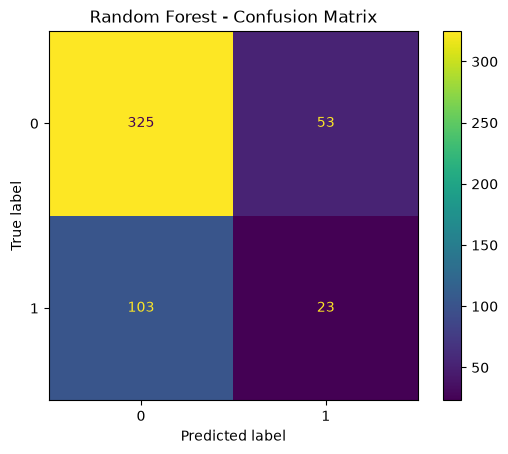

In [480]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

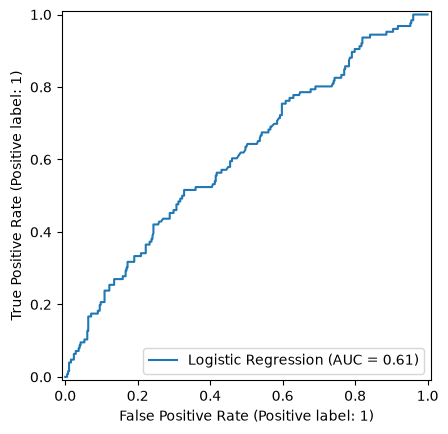

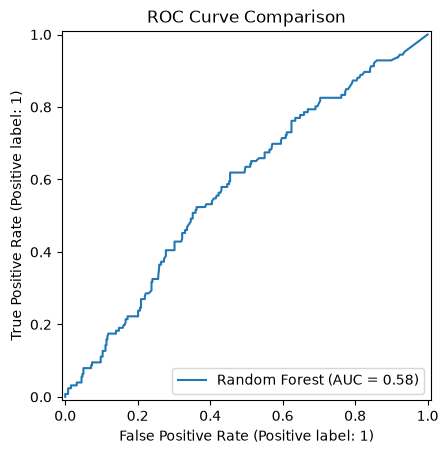

In [481]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    log_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.show()

The models were developed to identify ICU stays at higher risk of prolonged length of stay, defined as LOS above the 75th percentile. Only variables available or plausibly available near admission were used to reduce data leakage. Model performance was compared using Precision, Recall, F1-score and ROC-AUC. Results should be interpreted as exploratory and not as a validated clinical prediction tool.

In [482]:
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Precision: 0.3026315789473684
Recall: 0.18253968253968253
F1: 0.22772277227722773
ROC-AUC: 0.5800999412110524


In [483]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

results.round(3)

,Model,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.471,0.063,0.112,0.608
1,Random Forest,0.303,0.183,0.228,0.580


## Model Evaluation — Confusion Matrix

The confusion matrix provides a more intuitive view of how each model identifies prolonged ICU stays, particularly the number of positive cases that remain undetected.

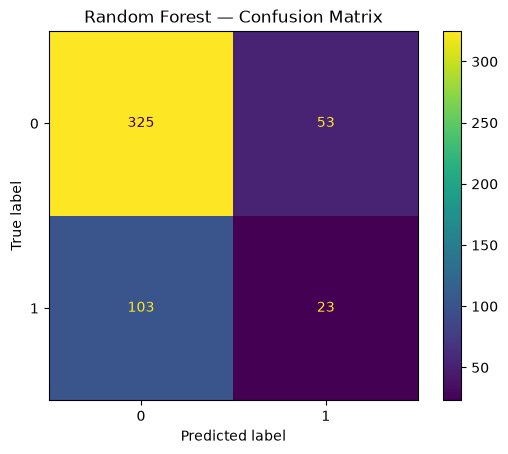

In [484]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest — Confusion Matrix")
plt.show()

## ROC Curve Comparison

ROC curves were used to compare the ability of both models to discriminate between prolonged and non-prolonged ICU stays across different classification thresholds.

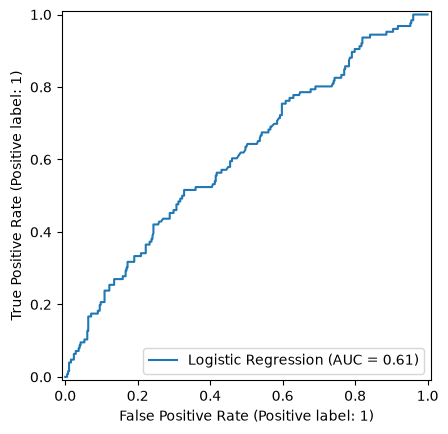

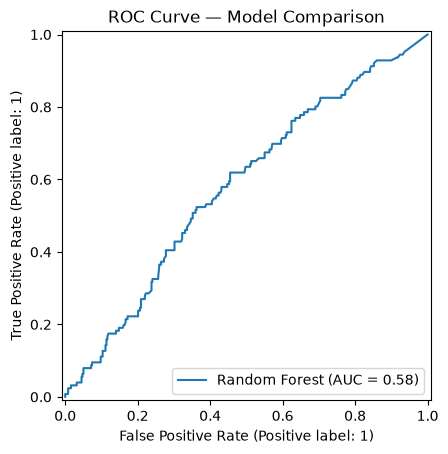

In [485]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    log_prob,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.title("ROC Curve — Model Comparison")
plt.show()

## Conclusions

Two baseline machine-learning models were evaluated for the identification of prolonged ICU length of stay: Logistic Regression and Random Forest.

Logistic Regression achieved the highest ROC-AUC (~0.61) and precision (~0.47), but showed very low recall (~0.06), indicating that most prolonged ICU stays were not identified.

Random Forest improved recall (~0.18) and F1-score (~0.23), although overall discrimination remained limited (ROC-AUC ~0.58).

These findings suggest that age, gender, ICU type, and APACHE severity score alone provide limited predictive information for prolonged ICU length of stay.

Only variables available or plausibly available near ICU admission were included in the models in order to reduce the risk of data leakage.

Future iterations could incorporate additional early clinical information, such as initial laboratory results, vital signs, and early organ-support requirements.

This analysis is exploratory and is not intended to represent a validated clinical prediction model.

In [486]:
results.to_csv(
    "../docs/model_metrics.csv",
    index=False
)